In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
import tqdm
import cv2
# Sequential model class used for building neural networks layer by layer
from tensorflow.keras.models import Sequential

# Common neural network layers:
# Dense: fully connected layer
# Conv2D: convolutional layer for image data
# MaxPooling2D: downsampling layer for reducing spatial dimensions
# Flatten: converts multi-dimensional data to 1D
# GlobalAveragePooling2D: reduces each feature map to a single number
# Dropout: prevents overfitting by randomly dropping neurons during training
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, GlobalAveragePooling2D,Dropout

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import models, layers
from keras.models import load_model
# This is a pretrained deep learning model (this can be used as a benchmark -> trained on large datasets)
from tensorflow.keras.applications import DenseNet121


In [2]:
train_data_path = r"C:\Users\khush\Desktop\BME 450\breastcancer_data\train"
test_data_path = r"C:\Users\khush\Desktop\BME 450\breastcancer_data\test"
val_data_path = r"C:\Users\khush\Desktop\BME 450\breastcancer_data\valid"

<h3><b>Train Data</b></h3>

In [3]:
#Train data
categories = ["0", "1"]
train_data = []
for category in categories:
    category_path = os.path.join(train_data_path, category)
    index = categories.index(category)
    for image in tqdm.tqdm(os.listdir(category_path)):
        img_path = os.path.join(category_path, image)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        train_data.append([img, index])

len(train_data)

100%|██████████| 803/803 [00:04<00:00, 169.55it/s]


2372

<h3><b>Test data</b></h3>

In [4]:
categories = ["0", "1"]
test_data = []
for category in categories:
    category_path = os.path.join(test_data_path, category)
    index = categories.index(category)
    for image in tqdm.tqdm(os.listdir(category_path)):
        img_path = os.path.join(category_path, image)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        test_data.append([img, index])
len(test_data)

100%|██████████| 128/128 [00:00<00:00, 165.06it/s]


336

<h3><b>Validation Dataset</b></h3>

In [5]:
categories = ["0", "1"]
val_data = []
for category in categories:
    category_path = os.path.join(val_data_path, category)
    index = categories.index(category)
    for image in tqdm.tqdm(os.listdir(category_path)):
        img_path = os.path.join(category_path, image)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        val_data.append([img, index])

len(val_data)

100%|██████████| 227/227 [00:01<00:00, 166.87it/s]


675

<h4>Data Shuffling</h4>

In [6]:
random.shuffle(train_data)
random.shuffle(test_data)
random.shuffle(val_data)

<h2>List to numpy array coversion</h2>

<h4>Train Data </h4>

In [7]:
x_train_list = []
y_train_list = []
for image, label in train_data:
    x_train_list.append(image)
    y_train_list.append(label)
    
# the normalisaiton to scale down the colour values. 
x_train = np.array(x_train_list)/255
y_train = np.array(y_train_list)

print(x_train.shape)

(2372, 224, 224, 3)


<h4>Test Data</h4>

In [8]:
x_test_list = []
y_test_list = []

for image, label in test_data:
    x_test_list.append(image)
    y_test_list.append(label)
    
# the normalisaiton to scale down the colour values. 
x_test = np.array(x_test_list)/255
y_test = np.array(y_test_list)

print(x_test.shape)

(336, 224, 224, 3)


<h4>Validation</h4>

In [9]:
x_val_list = []
y_val_list = []
for image, label in val_data:
    x_val_list.append(image)
    y_val_list.append(label)
    
# the normalisaiton to scale down the colour values. 
x_val = np.array(x_val_list)/255
y_val = np.array(y_val_list)

print(x_val.shape)

(675, 224, 224, 3)


<h2>Sample Visualisation</h2>

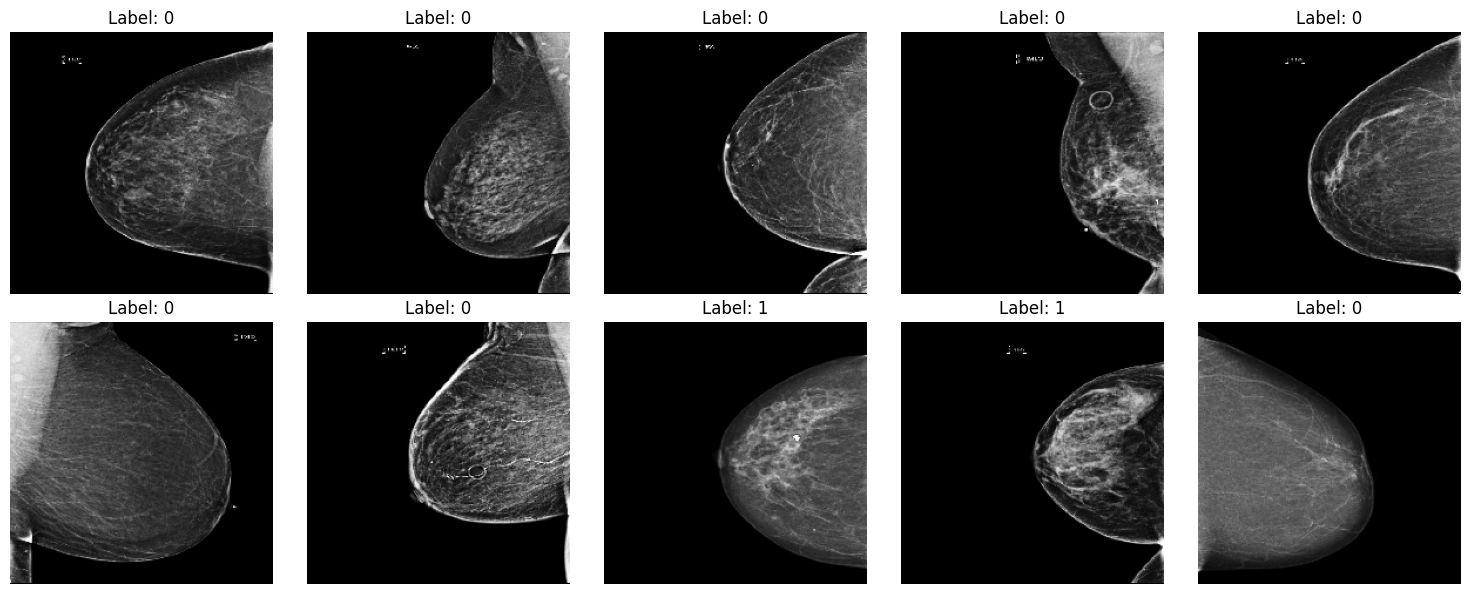

In [10]:
import matplotlib.pyplot as plt

# Display a few sample images from the training set
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(x_train[i])
    axes[i].set_title(f'Label: {y_train[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

<h2>CNN Model Option 1</h2>
<h4>4 layer model</h4>

In [ ]:
model = Sequential()
# 100 filter with 3x3 filter size
# model filter [100, 100, 64, 64]
model.add(Conv2D(100,(3, 3), activation = "relu", input_shape = (224, 224, 3)))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(100,(3, 3), activation = "relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64,(3, 3), activation = "relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64,(3, 3), activation = "relu"))
model.add(MaxPooling2D(2, 2))

# Classificiation Head [64, 32, 32] Neurons with dropout rates of [20, 30] percent
model.add(Flatten())
model.add(Dense(64, activation = "relu"))
model.add(Dropout(.2))
model.add(Dense(32, activation = "relu"))
model.add(Dropout(.3))
model.add(Dense(32, activation = "relu"))
model.add(Dense(1, activation = 'sigmoid'))

# Adam optimizer updates the model weights during training
# binary_crossentropy is used because this is a binary classification problem
model.compile(optimizer="adam", loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


C:\Users\khush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 100)  │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 100)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 100)  │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        57,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 780,549 (2.98 MB)

 Trainable params: 780,549 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training the CNN Model
history = model.fit(x_train, y_train, epochs = 20, validation_data=(x_val, y_val), verbose= 1)

# saving the triaining history file so we dont have to repeatedly train the model to make the graphs
import json
# Save trained model
model.save("breast_cancer_cnn_model.keras")

with open("training_history.json", "w") as f:
    json.dump(history.history, f)

print("Model and training history saved.")

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.6564 - loss: 0.6525 - val_accuracy: 0.6637 - val_loss: 0.6392
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - accuracy: 0.6615 - loss: 0.6405 - val_accuracy: 0.6637 - val_loss: 0.6477
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - accuracy: 0.6615 - loss: 0.6313 - val_accuracy: 0.6637 - val_loss: 0.6222
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - accuracy: 0.6615 - loss: 0.6259 - val_accuracy: 0.6637 - val_loss: 0.6213
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.6653 - loss: 0.6177 - val_accuracy: 0.6548 - val_loss: 0.6344
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.6758 - loss: 0.6113 - val_accuracy: 0.6652 - val_loss: 0.6131
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 209s 3s/step - accuracy: 0.6830 - loss: 0.5992 - val_accuracy: 0.6637 - val_loss: 0.6173
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 208s 3s/step - accuracy: 0.6876 - loss: 0.5944 - val_accuracy: 0.6563 - v

Plotting the grpahs and confusion matrix

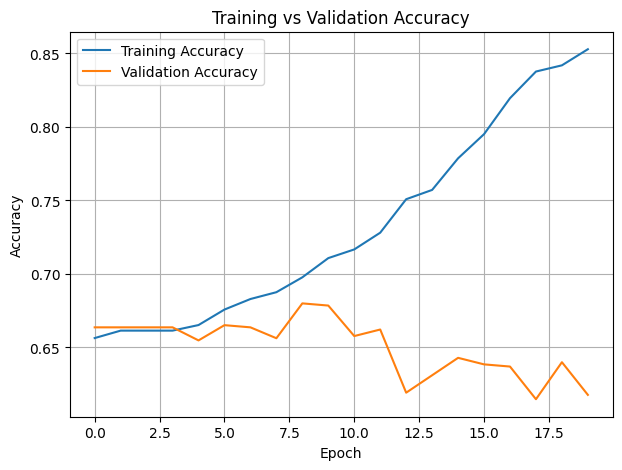

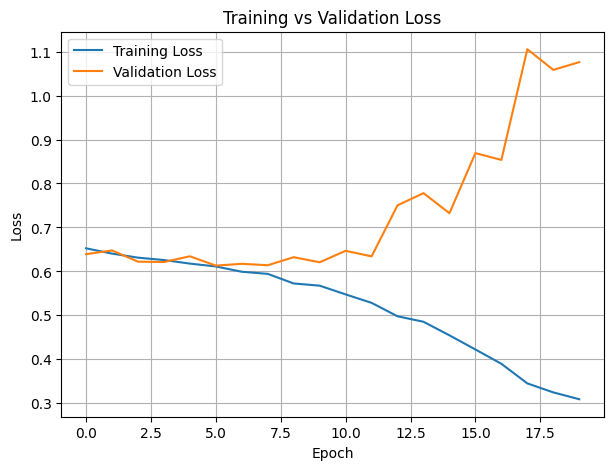

In [15]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix

11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
Confusion Matrix:
[[208   0]
 [128   0]]


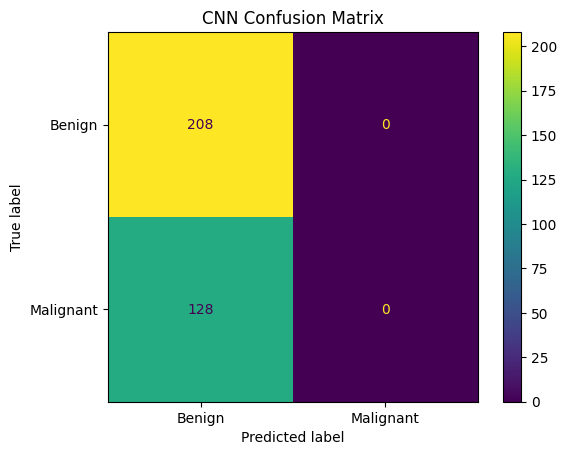

Classification Report:
              precision    recall  f1-score   support

      Benign       0.62      1.00      0.76       208
   Malignant       0.00      0.00      0.00       128

    accuracy                           0.62       336
   macro avg       0.31      0.50      0.38       336
weighted avg       0.38      0.62      0.47       336



In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

y_test_flat = np.array(y_test).flatten()

y_prob = model.predict(x_test).flatten()

threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test_flat, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(values_format="d")
plt.title("CNN Confusion Matrix")
plt.show()


<h1> ResNet18 Model </h1>

Using device: cpu
Classes: ['0', '1']
Class mapping: {'0': 0, '1': 1}
Training images: 2372
Validation images: 675
Test images: 336
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\khush/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:08<00:00, 5.41MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

...

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

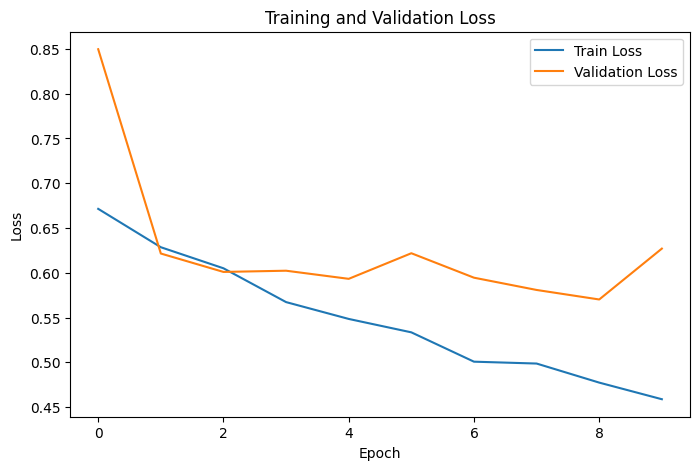

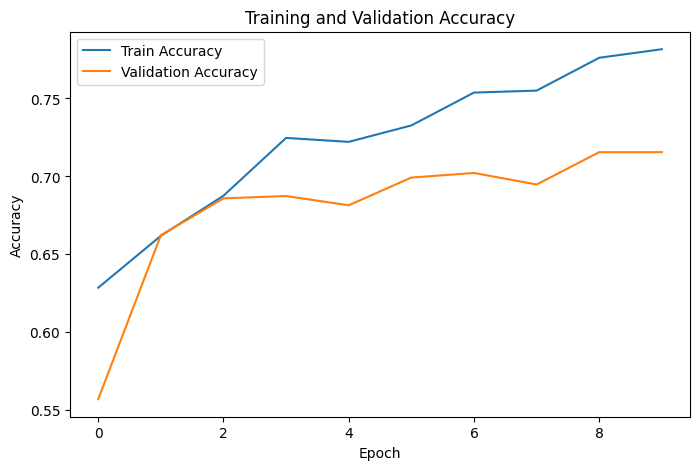

              precision    recall  f1-score   support

           0       0.69      0.92      0.79       208
           1       0.72      0.34      0.47       128

    accuracy                           0.70       336
   macro avg       0.71      0.63      0.63       336
weighted avg       0.70      0.70      0.67       336



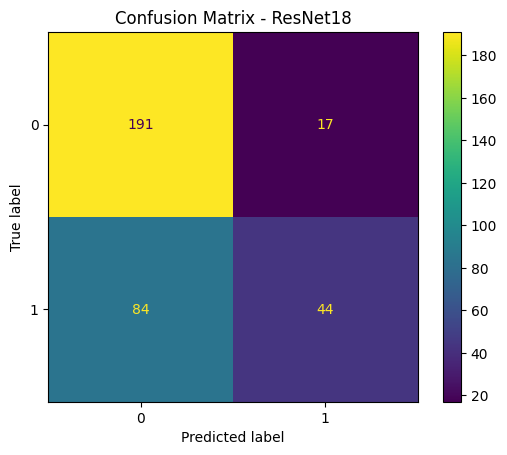

Model saved successfully.
Model loaded successfully.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Basic training settings
IMG_SIZE = 224
BATCH_SIZE = 16


# Data augmentation for training images
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Validation and test images are only resized and normalized
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Load image datasets from class-labeled folders
train_dataset = datasets.ImageFolder(train_data_path, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_data_path, transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(test_data_path, transform=val_test_transforms)


# Create data loaders for batching
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))


# Load pretrained ResNet18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)


# Replace final layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

print(model)


# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


EPOCHS = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


# Train and validate model
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    model.train()
    running_loss = 0.0
    running_corrects = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = running_corrects.double() / len(train_dataset)

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc.item())


    # Validation phase
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            val_running_loss += loss.item() * images.size(0)
            val_running_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc = val_running_corrects.double() / len(val_dataset)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc.item())

    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")


# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


# Evaluate model on test set
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# Print classification metrics
class_names = test_dataset.classes
print(classification_report(all_labels, all_preds, target_names=class_names))


# Display confusion matrix
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.title("Confusion Matrix - ResNet18")
plt.show()


# Save trained model weights
torch.save(model.state_dict(), "resnet18_breast_cancer_model.pth")

print("Model saved successfully.")


# Reload saved model
model = models.resnet18(weights=None)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model.load_state_dict(torch.load("resnet18_breast_cancer_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully.")

<h2>Densenet Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


# Convert image arrays to float32 for DenseNet preprocessing
x_train_densenet = x_train.astype("float32")
x_val_densenet = x_val.astype("float32")
x_test_densenet = x_test.astype("float32")


# Apply DenseNet121-specific preprocessing
x_train_densenet = preprocess_input(x_train_densenet)
x_val_densenet = preprocess_input(x_val_densenet)
x_test_densenet = preprocess_input(x_test_densenet)


# Check dataset shapes before model training
print("Training shape:", x_train_densenet.shape)
print("Validation shape:", x_val_densenet.shape)
print("Testing shape:", x_test_densenet.shape)

Training shape: (2372, 224, 224, 3)
Validation shape: (675, 224, 224, 3)
Testing shape: (336, 224, 224, 3)


In [ ]:
input_shape = (224, 224, 3)

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=input_shape)
)

# Freeze the pretrained base model first
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

# Binary classification output
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

#model compilation
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

checkpoint = ModelCheckpoint(
    "best_densenet121_model.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)
# Training Model
history = model.fit(
    x_train_densenet,
    y_train,
    validation_data=(x_val_densenet, y_val),
    epochs=20,
    batch_size=16,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

history = model.fit(
    x_train_densenet,
    y_train,
    validation_data=(x_val_densenet, y_val),
    epochs=20,
    batch_size=16,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)
#saving the model
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df.to_csv("densenet121_training_history.csv", index=False)

print("Training history saved as densenet121_training_history.csv")



29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,316,417 (27.91 MB)

 Trainable params: 278,913 (1.06 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 948ms/step - accuracy: 0.6270 - auc: 0.5199 - loss: 0.6614 - precision: 0.3385 - recall: 0.1131
Epoch 1: val_auc improved from None to 0.50514, saving model to best_densenet121_model.keras

Epoch 1: finished saving model to best_densenet121_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.6358 - auc: 0.5131 - loss: 0.6601 - precision: 0.3467 - recall: 0.0859 - val_accuracy: 0.6637 - val_auc: 0.5051 - val_loss: 0.6388 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 904ms/step - accuracy: 0.6396 - auc: 0.5001 - loss: 0.6605 - precision: 0.2124 - recall: 0.0226
Epoch 2: val_auc improved from 0.50514 to 0.54488, saving model to best_densenet121_model.keras

Epoch 2: finished saving model to best_densenet121_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.6492 - auc: 0.4961 - loss: 0.6565 - precision: 0.2041 - recall: 0.0125 - val_accu

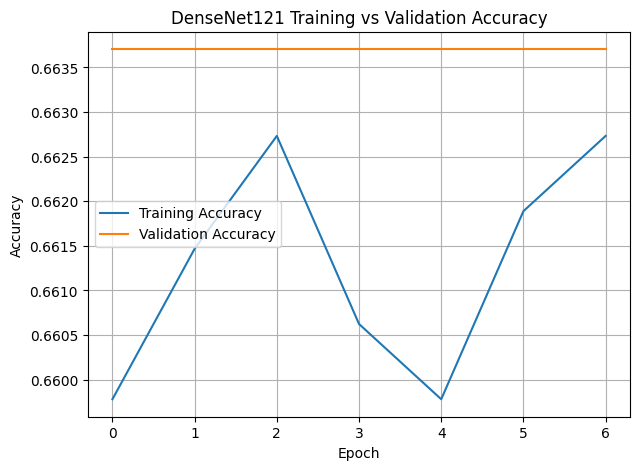

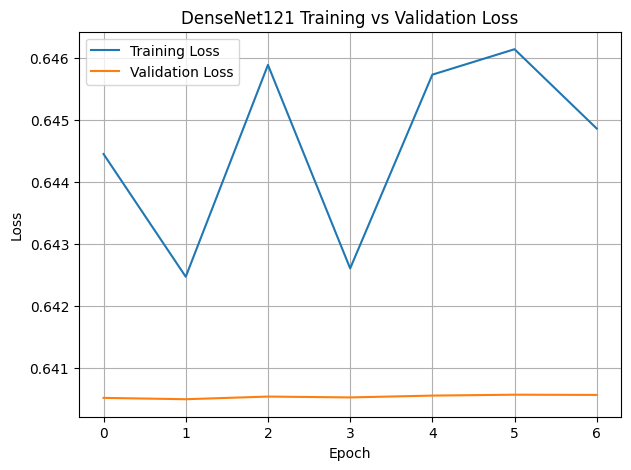

11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6190 - auc: 0.5672 - loss: 0.6629 - precision: 0.0000e+00 - recall: 0.0000e+00
loss: 0.6629
compile_metrics: 0.6190


In [20]:
# ============================================================
# Plot Accuracy
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet121 Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# Plot Loss
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# Test Set Evaluation
# ============================================================

test_results = model.evaluate(x_test_densenet, y_test, verbose=1)

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

In [ ]:

test_results = model.evaluate(x_test_densenet, y_test, verbose=1)

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6190 - auc: 0.5672 - loss: 0.6629 - precision: 0.0000e+00 - recall: 0.0000e+00
loss: 0.6629
compile_metrics: 0.6190


11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step

Threshold: 0.36
Predicted class counts: (array([1]), array([336]))
Confusion Matrix:
[[  0 208]
 [  0 128]]
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00       208
   Malignant       0.38      1.00      0.55       128

    accuracy                           0.38       336
   macro avg       0.19      0.50      0.28       336
weighted avg       0.15      0.38      0.21       336



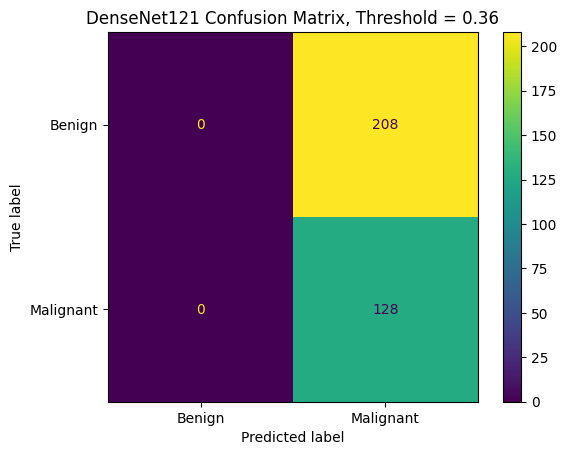


Threshold: 0.37
Predicted class counts: (array([0, 1]), array([  9, 327]))
Confusion Matrix:
[[  9 199]
 [  0 128]]
              precision    recall  f1-score   support

      Benign       1.00      0.04      0.08       208
   Malignant       0.39      1.00      0.56       128

    accuracy                           0.41       336
   macro avg       0.70      0.52      0.32       336
weighted avg       0.77      0.41      0.27       336



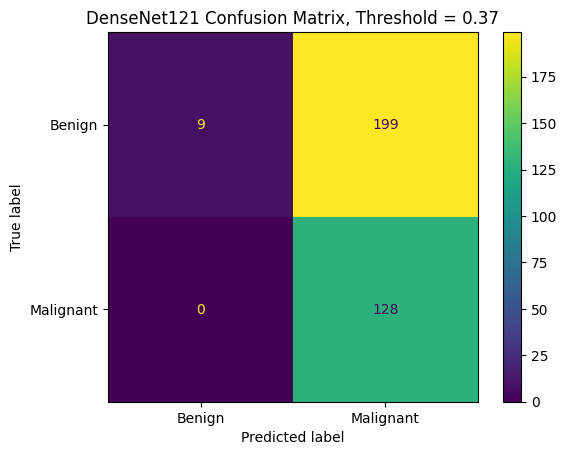


Threshold: 0.38
Predicted class counts: (array([0, 1]), array([ 87, 249]))
Confusion Matrix:
[[ 61 147]
 [ 26 102]]
              precision    recall  f1-score   support

      Benign       0.70      0.29      0.41       208
   Malignant       0.41      0.80      0.54       128

    accuracy                           0.49       336
   macro avg       0.56      0.55      0.48       336
weighted avg       0.59      0.49      0.46       336



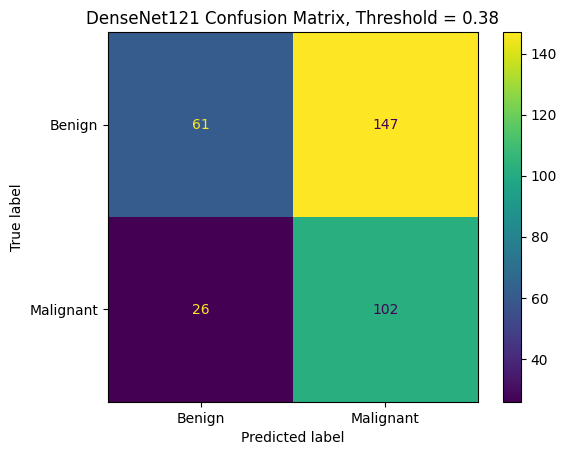


Threshold: 0.39
Predicted class counts: (array([0, 1]), array([281,  55]))
Confusion Matrix:
[[179  29]
 [102  26]]
              precision    recall  f1-score   support

      Benign       0.64      0.86      0.73       208
   Malignant       0.47      0.20      0.28       128

    accuracy                           0.61       336
   macro avg       0.55      0.53      0.51       336
weighted avg       0.57      0.61      0.56       336



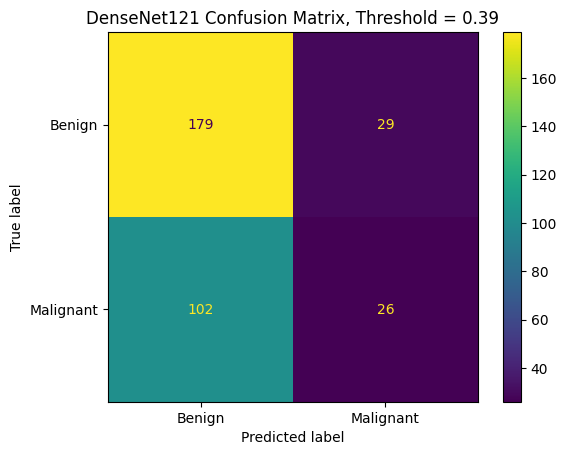


Threshold: 0.4
Predicted class counts: (array([0, 1]), array([334,   2]))
Confusion Matrix:
[[206   2]
 [128   0]]
              precision    recall  f1-score   support

      Benign       0.62      0.99      0.76       208
   Malignant       0.00      0.00      0.00       128

    accuracy                           0.61       336
   macro avg       0.31      0.50      0.38       336
weighted avg       0.38      0.61      0.47       336



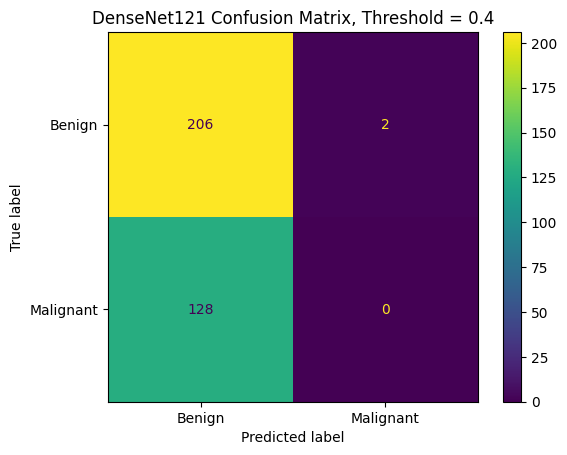

In [ ]:
# Testing Thresholds
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_test_flat = np.array(y_test).flatten()
y_prob = model.predict(x_test_densenet).flatten()

thresholds = [0.36, 0.37, 0.38, 0.39, 0.40]

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test_flat, y_pred)

    print("\n====================================================")
    print("Threshold:", threshold)
    print("Predicted class counts:", np.unique(y_pred, return_counts=True))
    print("Confusion Matrix:")
    print(cm)

    print(classification_report(
        y_test_flat,
        y_pred,
        target_names=["Benign", "Malignant"],
        zero_division=0
    ))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )

    disp.plot(values_format="d")
    plt.title(f"DenseNet121 Confusion Matrix, Threshold = {threshold}")
    plt.show()